# Деревья решений

```
Do you want an iterpretable model, or the one that works? - Yann LeCun
```

![alt](../data/1.webp)


Источник: Explainable Artificial Intelligence (XAI): Concepts, Taxonomies, Opportunities and Challenges toward Responsible AI.

`Решающее дерево` (aka Дерево решений aka Дерево принятия решений) - это непараметрический метод обучения с учителем, используемый для **классификации** и **регрессии**. 

Основная идея состоит в том, чтобы создать модель, которая предсказывает значение целевой переменной на основе множества простых правил принятия решений, выведенных на основе данных. Дерево можно рассматривать как **кусочно-постоянную аппроксимацию**.

## Что такое дерево?

![alt](../data/2.avif)


Дерево **в нашем понимании** - связный **ориентированный** ациклический граф, причем в каждую вершину входит не более одного ребра.

![alt](../data/3.png)


**Пример выборки**:

Задача Фишера о классификации цветков ириса. Это задача мультиклассовой классификации. В выборке представлены 3 класса по 50 объектов на каждый класс. Каждый объект обладает 4-мя числовыми признаками.

![alt](../data/5.png)

## Разделяющая функция

`Разделяющая функция` (`split function`) - функция, определяющая следующий узел из $m$ потоков $i$-го внутреннего узла для элемента $\textbf{x} \in X$

$h(\textbf{x}, w_i): \mathbb{R}^D \times W \rightarrow \{0, m-1\}$,

$w_i \in W$ - параметры разделяющей функции

Обычно на практике рассматривают `бинарные деревья решений` (binary decision tree)

`Бинарным деревом решений` называют дерево решений, у которого каждый разделяющий узел имеет ровно два потомка.

$h(\textbf{x}, w_i): \mathbb{R}^D \times W \rightarrow \{0, 1\}$,

$w_i \in W$ - параметры разделяющей функции

### Выбор характеристик

Функция выбора характеристик (Feature Selector Function, FSF) - это функция, получающая на вход признаковое описание объекта $\textbf{x} \in X$ и возвращающая вектор $\dot{\mathbf{x}}$ меньшей размерности, содержащий подмножество компонент исходного вектора $\mathbf{x}$

$\psi(\mathbf{x}) : \mathbb{R}^D \rightarrow \mathbb{R}^{\dot{D}}$, причём, как правило, $D << \dot{D}$

`Важно:` Функция $\psi$ часто является персонализированной для конкретного узла

Мы хотим построить underfit`ящий классификатор в каждом узле.

`Пример:`

Пусть $\mathbf{x} \in \mathbb{R}^D$ (Для конкретики $D = 6$)

$\mathbf{x} = (x_1, x_2, x_3, x_4, x_5, x_6)$

$\psi(\mathbf{x}) = (x_1, x_3)$

Отдельный интерес представляют FSF вот такого вида: $\psi(\mathbf{x}) = x_j$

## Виды разделяющих функций

### Axis-aligned hyperplane weak learner

![alt](../data/6.png)

$h(\mathbf{x}, w_i) = [t_1 > \psi(\mathbf{x}) > t_2)]$,

$w_i = (\psi, t_1, t_2)$, $\psi(\mathbf{x}) = x_j$

### General oriented hyperplane

![alt](../data/7.png)

$h(\mathbf{x}, w_i) = [t_1 > \psi(\mathbf{x})^\top \mathbf{w} > t_2)]$,

$w_i = (\psi,\mathbf{w}, t_1, t_2)$

В данном случае $\dot{D} \geq 2$

### Quadratic surface (conic in 2D).

![alt](../data/8.png)

$h(\mathbf{x}, w_i) = [t_1 > \phi(\psi(\mathbf{x}))^\top \mathbf{w} > t_2)]$,

$w_i = (\psi,\mathbf{w}, t_1, t_2)$

Мы будем работать с разделяющими функциями первого вида: $h(\mathbf{x}, w_i) = [t_1 > \psi(\mathbf{x}) > t_2)]$. Более того, всегда один из параметров $t_1 = +\infty$ или $t_2 = -\infty$, а это значит, что $h$ является **пороговой функцией**.

![alt](../data/9.png)

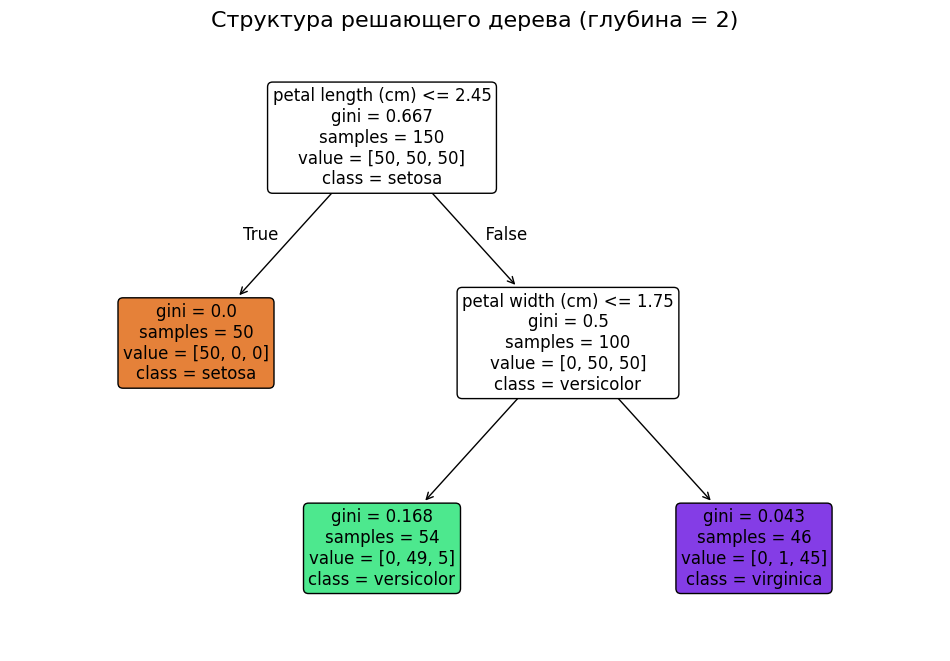

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree

iris = load_iris()
X, y = iris.data, iris.target

clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X, y)

plt.figure(figsize=(12, 8), dpi=100)
plot_tree(clf,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=12)

plt.title("Структура решающего дерева (глубина = 2)", fontsize=16)
plt.show()

![alt](../data/4.png)

## Главные вопросы?

* Как создать внутренний узел?
* Когда создавать терминальный узел?
* Как создать терминальный узел?

### Как создать внутренний узел? Критерий ветвления

Ввёдем **ПАРОЧКУ** обозначений 🤡

$C_1, C_2, ..., C_K$ - набор классов

$S_i$ - множество объектов обучающей выборки, дошедших до узла $i$.

$S^{(k)}_i$ - множество объектов обучающей выборки класса $C_k$, дошедших до узла $i$.

$N_i = |S_i|$ - количество объектов обучающей выборки, дошедших до узла $i$.

***

$N^{(k)}_i = |S^{(k)}_i|$ - количество объектов обучающей выборки класса $C_k$, дошедших до узла $i$.


$S_{ij}$ - множество объектов обучающей выборки, дошедших до узла $j$, потомка узла $i$.

$S^{(k)}_{ij}$ - множество объектов обучающей выборки класса $C_k$, дошедших до узла $j$, потомка узла $i$.

$N_{ij} = |S_{ij}|$ - количество объектов обучающей выборки, дошедших до узла $j$, потомка узла $i$.


$N^{(k)}_{ij} = |S^{(k)}_{ij}|$ - количество объектов обучающей выборки класса $C_k$, дошедших до узла $j$, потомка узла $i$.


Хочется как-то учитывать Разнородность (Гетерогенность, $\mathbb{H}$ eterogeneity) после разбиения исходной выборки $S_0=X^\mathcal{l}$ на подвыборки $S_1 \sqcup S_2$


$$\frac{N_1}{N_0}\mathbb{H}(S_1) + \frac{N_2}{N_0}\mathbb{H}(S_2) \rightarrow min$$

![alt](../data/11.gif)

Что за функция $\mathbb{H}$?

$\mathbb{H}(U)$ называют `неопределённостью` (`impurity`):

1. $\mathbb{H}(U)$ минимальна и равна нулю, когда $U$ состоит из объектов одного класса
2. Максимальна тогда, когда объекты $U$ являются интерпретацией равномерного распределения $(\frac{1}{|U|})$
3. Симметрична, т.е. не зависит от переименования классов





![alt](../data/12.png)


Энтропия (или количество информации)

`Entropy`
$$\mathbb{H} =  -\sum_{i}p_i \ log(p_i)$$

Существуют и другие функции неопределённости:

`Missclassification`:
$$\mathbb{H} = 1 - \max_i({p_i})$$

`Gini`
$$ \mathbb{H} = 1 -\sum_{i}p_i^2$$

Рассмотрим самый простой одномерный случай

![alt](../data/10.png)

Здесь 9 синих шариков и 11 желтых. 

Если мы наудачу вытащили шарик, то он с вероятностью   $p_1=\frac{9}{20}$ будет синим и с вероятностью  $p_2=\frac{11}{20}$ – желтым. 

Значит, энтропия состояния  $S_0$ равна $\mathbb{H}(S_0) = -\frac{9}{20}log_2{\frac{9}{20}}-\frac{11}{20}log_2{\frac{11}{20}} \approx 1$. 

Теперь посмотрим, как изменится энтропия, если разбить шарики на две группы – с координатой меньше либо равной 12 и больше 12.

Т. е. введём разделяющую функцию $h(\mathbf{x}, w) = [x \leq 12]$

 ![alt](../data/14.png)

1. В левой группе оказалось 13 шаров, из которых 8 синих и 5 желтых. 

Энтропия этой группы равна $\mathbb{H}(S_1) = -\frac{5}{13}log_2{\frac{5}{13}}-\frac{8}{13}log_2{\frac{8}{13}} \approx 0.96$. 

2. В правой группе оказалось 7 шаров, из которых 1 синий и 6 желтых. 

Энтропия правой группы равна $\mathbb{H}(S_2) = -\frac{1}{7}log_2{\frac{1}{7}}-\frac{6}{7}log_2{\frac{6}{7}} \approx 0.6$. 

Как видим, энтропия уменьшилась в обеих группах по сравнению с начальным состоянием, хоть в левой и не сильно. Поскольку энтропия – по сути степень хаоса (или неопределенности) в системе, **уменьшение энтропии** называют **приростом информации**
 
Формально прирост информации ``(information gain, IG)`` при разбиении выборки по признаку $f$ (в нашем примере это признак "$x \leq 12$") определяется как 

$$\Large IG(x \leq 12) = S_O - \sum_{i}\frac{N_i}{N}S_i$$

Получается, разделив шарики на две группы по признаку "координата меньше либо равна 12", мы уже получили более упорядоченную систему, чем в начале. Продолжим деление шариков на группы до тех пор, пока в каждой группе шарики не будут одного цвета. 

![alt](../data//13.png)

Тогда, при выборе очередного значения признака для последующего деления мы посчитаем

$$IG = \mathbb{H}(S_i) - \sum_i \frac{N_{ij}}{N_i}\mathbb{H}(S_{ij}) \rightarrow \max_w$$

Заметим, что $\mathbb{H}(S_i)$ уже зафиксировано, значит наша задача уменьшит абсолютное значение вычитаемого, т.е.:

$$\mathcal{L} = \sum_i \frac{N_{ij}}{N_i}\mathbb{H}(S_{ij}) \rightarrow \min_w$$

Никакими градиентными методами тут и не пахнет, здесь используем методы $0$-го порядка.



### Когда создавать терминальный узел?

`Stopping Criteria`

Терминальный узел создаётся, если выполнено одно из условий:

* Достигнута глубина дерева $d$
* $N_i$ < n
* $\mathbb{H}(S_i) < \varepsilon$

### Как создать терминальный узел?

$$t = \argmax_kN^{(k)}_i$$


## Дерево решений в задачах регрессии

Главное отличие `Regression Tree` от классификационного — в том, что дерево предсказывает не дискретную «метку», а вещественное число (среднее значение целевой переменной в листе).

![alt](../data/15.png)

### Критерий информативности $\mathbb{H}$

В регрессии мы не можем считать Энтропию или Джини, потому что у нас нет долей классов. Вместо этого используется MSE (Mean Squared Error) или MAE (Mean Absolute Error).


Для узла $U$ функция неопределенности выглядит так:

$$\mathbb{H}(U) = \frac{1}{|U|}\sum_{i \ \in \ U}(y_i- \bar{y})^2$$

Где $\bar{y}$ реднее арифметическое ответов всех объектов в этом узле. Дерево стремится разбивать данные так, чтобы в дочерних узлах значения $y$ были максимально близки к своему среднему (минимизация дисперсии).

### Ответ в листе

Если в классификации ответом является `мода` (самый частый класс), то в регрессии ответом листа является `среднее значение` всех обучающих объектов, попавших в этот лист

### Форма решающей поверхности

График предсказаний дерева регрессии (если смотреть на него в 2D) всегда будет ступенчатым. Оно не умеет проводить наклонные линии, оно просто «рубит» пространство на квадраты и в каждом квадрате назначает константное число.
Критический нюанс: Дерево решений не умеет экстраполировать. Если в обучающей выборке максимальная цена дома была 10 млн, дерево никогда не предскажет 11 млн, даже если на вход придет дворец, потому что среднее в листьях ограничено диапазоном тренировочных данных.